position
QB    15.317956
RB    10.033611
TE     6.221685
WR     9.467119
Name: fantasy_points_ppr, dtype: float64
position
QB    15.317956
RB    10.033611
TE     6.221685
WR     9.467119
Name: fantasy_points_ppr, dtype: float64


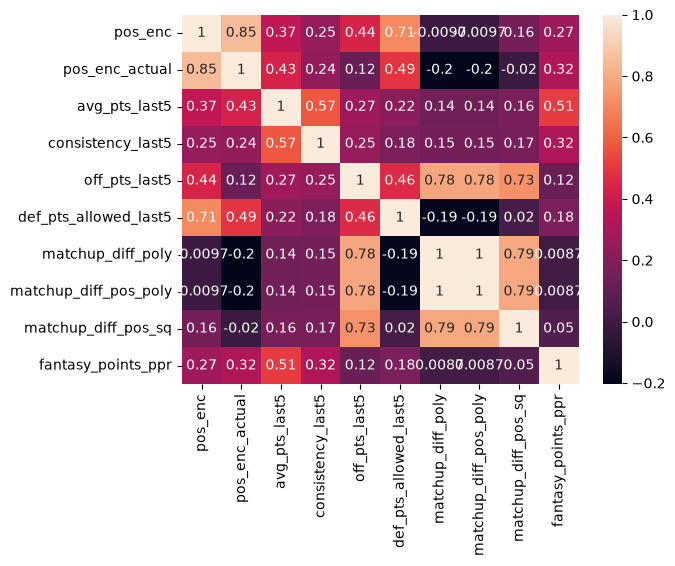

fantasy_points_ppr        1.000000
avg_pts_last5             0.508879
pos_x_avg_pts             0.497034
pos_x_consistency         0.376847
consistency_last5         0.318005
pos_enc_actual            0.316394
avg_attempts_last5        0.273089
pos_x_attempts            0.272900
pos_x_carries             0.242241
pos_x_off_pts             0.230498
avg_carries_last5         0.210776
pos_x_targets             0.178042
pos_x_target_share        0.172537
avg_targets_last5         0.150617
avg_target_share_last5    0.143800
Name: fantasy_points_ppr, dtype: float64
position
QB    16.645956
RB    19.944833
TE    12.160599
WR    30.615393
Name: off_pts_last5, dtype: float64
position
QB    18.506433
RB    12.152470
TE     7.031500
WR    18.808781
Name: def_pts_allowed_last5, dtype: float64
fantasy_points_ppr        1.000000
matchup_diff_norm         0.064180
matchup_diff_norm_poly    0.063762
matchup_diff_norm_sq     -0.031284
Name: fantasy_points_ppr, dtype: float64


KeyError: "['recieving_yards', 'recieving_tds'] not in index"

In [289]:
# %pip install nflreadpy
# %pip install pyarrow

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nflreadpy as nfl
from IPython.display import display

# for data relevancy (and size) only select most recent 3 seasons
seasons = [2020, 2021, 2022, 2023, 2024]
# collect player stats/data
df = nfl.load_player_stats(seasons=seasons).to_pandas()
# address NaNs
df = df.dropna(subset=['player_name'])

##### PLAYER ROLLING AVERAGES
# sort for rolling calcs
df = df.sort_values(['player_name', 'season', 'week']).reset_index(drop=True)
# rolling 5 across season boundaries
df['avg_pts_last5'] = df.groupby('player_name')['fantasy_points_ppr'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['avg_attempts_last5'] = df.groupby('player_name')['attempts'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['avg_carries_last5'] = df.groupby('player_name')['carries'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['avg_targets_last5'] = df.groupby('player_name')['targets'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['avg_target_share_last5'] = df.groupby('player_name')['target_share'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
# consistency - low std = less volatile
df['consistency_last5'] = df.groupby('player_name')['fantasy_points_ppr'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=2).std()
)

##### CUT DOWN ON 0s in output
# limit to meaningful contributors only
df = df[
    ((df['position'] == 'QB') & (df['avg_attempts_last5'] >= 10)) |
    ((df['position'] == 'RB') & (df['avg_carries_last5'] >= 3)) |
    ((df['position'] == 'WR') & (df['avg_targets_last5'] >= 2)) |
    ((df['position'] == 'TE') & (df['avg_targets_last5'] >= 1))
].copy()

##### DEFENSIVE TEAM PTS ALLOWED
# calculate position specific yards and tds allowed per defense per week
def_stats = df.groupby(['opponent_team', 'position', 'season', 'week']).agg(
    pass_yds=('passing_yards', 'sum'),
    rush_yds=('rushing_yards', 'sum'),
    rec_yds=('receiving_yards', 'sum'),
    pass_tds=('passing_tds', 'sum'),
    rush_tds=('rushing_tds', 'sum'),
    rec_tds=('receiving_tds', 'sum')
).reset_index()

# calculate non-spec teams stats
# QBs => passing yards + passing tds weighted
def_stats.loc[def_stats['position'] == 'QB', 'def_pts_allowed'] = \
    (def_stats['pass_yds'] * 0.04) + (def_stats['pass_tds'] * 6)
# RBs => rushing yards + rushing tds weighted
def_stats.loc[def_stats['position'] == 'RB', 'def_pts_allowed'] = \
    (def_stats['rush_yds'] * 0.1) + (def_stats['rush_tds'] * 6)
# WR/TE => receiving yards + receiving tds weighted
def_stats.loc[def_stats['position'].isin(['WR', 'TE']), 'def_pts_allowed'] = \
    (def_stats['rec_yds'] * 0.1) + (def_stats['rec_tds'] * 6)

# calc def_pts_allowed_last5
def_stats = def_stats.sort_values(['opponent_team', 'position', 'season', 'week'])
def_stats['def_pts_allowed_last5'] = def_stats.groupby(['opponent_team', 'position'])['def_pts_allowed'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# merge back into df
df = df.merge(def_stats[['opponent_team', 'position', 'season', 'week', 'def_pts_allowed_last5']],
              on=['opponent_team', 'position', 'season', 'week'], how='left')

##### OFFENSIVE TEAM PTS SCORED
off_stats = df.groupby(['team', 'position', 'season', 'week'])['fantasy_points_ppr'].sum().reset_index()
off_stats = off_stats.sort_values(['team', 'position', 'season', 'week'])
off_stats['off_pts_last5'] = off_stats.groupby(['team', 'position'])['fantasy_points_ppr'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# merge offensive stats into df
df = df.merge(off_stats[['team', 'position', 'season', 'week', 'off_pts_last5']],
              on=['team', 'position', 'season', 'week'], how='left')

##### MATCHUP DIFFERENTIAL
df['matchup_diff'] = df['off_pts_last5'] - df['def_pts_allowed_last5']
# df['matchup_diff'].plot(kind='hist')
# plt.show()

# histogram is clearly poly - change feature to poly
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
match_poly = poly.fit_transform(df[['matchup_diff']].fillna(0))
df['matchup_diff_poly'] = match_poly[:, 0]
df['matchup_diff_sq'] = match_poly[:, 1]

##### OFFENSIVE POS PTS SCORED
# position specific offensive rolling average
off_stats_pos = df.groupby(['team', 'position', 'season', 'week'])['fantasy_points_ppr'].sum().reset_index()
off_stats_pos = off_stats_pos.sort_values(['team', 'position', 'season', 'week'])
off_stats_pos['off_pts_pos_last5'] = off_stats_pos.groupby(['team', 'position'])['fantasy_points_ppr'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df = df.merge(off_stats_pos[['team', 'position', 'season', 'week', 'off_pts_pos_last5']],
              on=['team', 'position', 'season', 'week'], how='left')

# now matchup diff is truly position specific
df['matchup_diff_pos'] = df['off_pts_pos_last5'] - df['def_pts_allowed_last5']
#############################################################################################################################
##### ENCODE POSITIONS
position_map = {'QB': 4, 'WR': 3, 'RB': 2, 'TE': 1}
df['pos_enc'] = df['position'].map(position_map)

pos_avg_map = {'QB': 15.3, 'RB': 10.0, 'WR': 9.5, 'TE': 6.2}
df['pos_enc_actual'] = df['position'].map(pos_avg_map)

# multiply pos_enc with strongest features
df['pos_x_avg_pts'] = df['pos_enc'] * df['avg_pts_last5']
df['pos_x_consistency'] = df['pos_enc'] * df['consistency_last5']
df['pos_x_off_pts'] = df['pos_enc'] * df['off_pts_last5']

df[['pos_enc', 'pos_x_avg_pts', 'pos_x_consistency', 
          'pos_x_off_pts', 'fantasy_points_ppr']].corr()['fantasy_points_ppr'].sort_values(ascending=False)

# encode by actual average scoring per position
pos_avg = df.groupby('position')['fantasy_points_ppr'].mean()
print(pos_avg)
df['pos_enc_actual'] = df['position'].map(pos_avg)

# now multiply
df['pos_actual_x_avg_pts'] = df['pos_enc_actual'] * df['avg_pts_last5']

df[['pos_enc_actual', 'pos_actual_x_avg_pts', 
          'fantasy_points_ppr']].corr()['fantasy_points_ppr'].sort_values(ascending=False)

# polynomial transform
match_poly = poly.fit_transform(df[['matchup_diff_pos']].fillna(0))
df['matchup_diff_pos_poly'] = match_poly[:, 0]
df['matchup_diff_pos_sq'] = match_poly[:, 1]

# encode by actual average scoring per position
pos_avg = df.groupby('position')['fantasy_points_ppr'].mean()
print(pos_avg)
df['pos_enc_actual'] = df['position'].map(pos_avg)

# now multiply
df['pos_actual_x_avg_pts'] = df['pos_enc_actual'] * df['avg_pts_last5']

df[['pos_enc_actual', 'pos_actual_x_avg_pts', 
          'fantasy_points_ppr']].corr()['fantasy_points_ppr'].sort_values(ascending=False)

# check correlation
corr = df[['pos_enc', 'pos_enc_actual', 'avg_pts_last5', 'consistency_last5', 
           # 'avg_target_share_last5', 'avg_targets_last5', 'avg_carries_last5', 'avg_attempts_last5',
           'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_poly', 'matchup_diff_pos_poly', 'matchup_diff_pos_sq', 'fantasy_points_ppr']].corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

# multiply pos_enc_actual with strongest features
df['pos_x_avg_pts'] = df['pos_enc_actual'] * df['avg_pts_last5']
df['pos_x_consistency'] = df['pos_enc_actual'] * df['consistency_last5']
df['pos_x_off_pts'] = df['pos_enc_actual'] * df['off_pts_last5']
df['pos_x_attempts'] = df['pos_enc_actual'] * df['avg_attempts_last5']
df['pos_x_carries'] = df['pos_enc_actual'] * df['avg_carries_last5']
df['pos_x_targets'] = df['pos_enc_actual'] * df['avg_targets_last5']
df['pos_x_target_share'] = df['pos_enc_actual'] * df['avg_target_share_last5']

print(df[['pos_x_avg_pts', 'pos_x_consistency', 'pos_x_off_pts', 'avg_pts_last5', 'consistency_last5',
          'avg_target_share_last5', 'avg_targets_last5', 'avg_carries_last5', 'avg_attempts_last5',
    'pos_x_attempts', 'pos_x_carries', 'pos_x_targets', 'pos_x_target_share', 'pos_enc_actual',
    'fantasy_points_ppr']].corr()['fantasy_points_ppr'].sort_values(ascending=False))

# get average off and def pts allowed per position
off_pos_avg = df.groupby('position')['off_pts_last5'].mean()
def_pos_avg = df.groupby('position')['def_pts_allowed_last5'].mean()

print(off_pos_avg)
print(def_pos_avg)

# normalize off and def by position average
df['off_pts_normalized'] = df['off_pts_last5'] / df['position'].map(off_pos_avg)
df['def_pts_normalized'] = df['def_pts_allowed_last5'] / df['position'].map(def_pos_avg)

# normalized matchup diff
# > 1 means offense scores more than average for that position
# < 1 means defense allows less than average for that position
df['matchup_diff_norm'] = df['off_pts_normalized'] - df['def_pts_normalized']

poly = PolynomialFeatures(degree=2, include_bias=False)
match_poly = poly.fit_transform(df[['matchup_diff_norm']].fillna(0))
df['matchup_diff_norm_poly'] = match_poly[:, 0]
df['matchup_diff_norm_sq'] = match_poly[:, 1]

print(df[['matchup_diff_norm', 'matchup_diff_norm_poly', 
    'matchup_diff_norm_sq', 'fantasy_points_ppr']].corr()['fantasy_points_ppr'].sort_values(ascending=False))
#############################################################################################################################

### SPLIT BY POSITION
qb_df = df[df['position'] == 'QB'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'pos_x_attempts', 'pos_x_carries',
    'avg_pts_last5', 'avg_attempts_last5', 'avg_carries_last5',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_poly', 'matchup_diff_pos_poly', 'matchup_diff_pos_sq',
    'fantasy_points_ppr'
]].copy()

rb_df = df[df['position'] == 'RB'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_carries_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'pos_x_carries', 'pos_x_targets',
    'pos_x_target_share',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_poly', 'matchup_diff_pos_poly', 'matchup_diff_pos_sq',
    'fantasy_points_ppr'
]].copy()

wr_df = df[df['position'] == 'WR'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'pos_x_targets', 'pos_x_target_share', 'recieving_yards', 'recieving_tds', 
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_poly', 'matchup_diff_pos_poly', 'matchup_diff_pos_sq',
    'fantasy_points_ppr'
]].copy()

te_df = df[df['position'] == 'TE'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'pos_x_targets', 'pos_x_target_share',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_poly', 'matchup_diff_pos_poly', 'matchup_diff_pos_sq',
    'fantasy_points_ppr'
]].copy()

### VISUALIZE
fig, ax = plt.subplots(figsize=(12, 6))

qb_df['fantasy_points_ppr'].plot(kind='hist', ax=ax, bins=30, alpha=0.5, label='QB')
rb_df['fantasy_points_ppr'].plot(kind='hist', ax=ax, bins=30, alpha=0.5, label='RB')
wr_df['fantasy_points_ppr'].plot(kind='hist', ax=ax, bins=30, alpha=0.5, label='WR')
te_df['fantasy_points_ppr'].plot(kind='hist', ax=ax, bins=30, alpha=0.5, label='TE')

ax.set_title('Fantasy Points PPR Distribution by Position')
ax.set_xlabel('Fantasy Points PPR')
ax.set_ylabel('Count')
ax.legend()
plt.show()

##### ONE HOT
df = pd.get_dummies(df, columns=['position'], prefix='pos')
df[['pos_QB', 'pos_RB', 'pos_WR', 'pos_TE', 'fantasy_points_ppr']].corr()['fantasy_points_ppr'].sort_values(ascending=False)

##### MODEL BUILD
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# final feature set
feature_cols = [
    'pos_enc_actual',
    'avg_pts_last5', 'pos_x_consistency',
    'pos_x_attempts', 'pos_x_carries', 'pos_x_targets', 'pos_x_target_share'
]

# drop NaNs from rolling features (early season weeks with no history)
df_model = df[feature_cols + ['fantasy_points_ppr']].dropna()

X = df_model[feature_cols]
y = df_model['fantasy_points_ppr']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# fit ridge model
model = Ridge()
model.fit(X_train, y_train)

# scores
print(f'Train score: {model.score(X_train, y_train):.4f}')
print(f'Test score:  {model.score(X_test, y_test):.4f}')

# metrics
y_pred = model.predict(X_test)
print(f'MAE:  {mean_absolute_error(y_test, y_pred):.4f}')
print(f'MSE:  {mean_squared_error(y_test, y_pred):.4f}')
print(f'R2:   {r2_score(y_test, y_pred):.4f}')

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = Ridge()
model_scaled.fit(X_train_scaled, y_train)

print(f'Train score: {model_scaled.score(X_train_scaled, y_train):.4f}')
print(f'Test score:  {model_scaled.score(X_test_scaled, y_test):.4f}')

from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor()
model_knn.fit(X_train_scaled, y_train)

print(f'Train score: {model_knn.score(X_train_scaled, y_train):.4f}')
print(f'Test score:  {model_knn.score(X_test_scaled, y_test):.4f}')

for k in [25, 50, 75, 100, 150, 200]:
    model_knn = KNeighborsRegressor(n_neighbors=k)
    model_knn.fit(X_train_scaled, y_train)
    print(f'k={k}: Train={model_knn.score(X_train_scaled, y_train):.4f} Test={model_knn.score(X_test_scaled, y_test):.4f}')

##### CLUSTERS???
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# features that would cluster well
cluster_features = [
    'avg_pts_last5', 'consistency_last5', 
    'pos_enc_actual', 'pos_x_avg_pts'
]

# drop NaNs and keep index
df_cluster = df[cluster_features].dropna().copy()

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# try different cluster counts
for k in [3, 4, 5, 6, 8]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df_cluster['cluster'] = kmeans.fit_predict(X_scaled)
    df['cluster'] = df_cluster['cluster']
    
    print(f'\n--- k={k} ---')
    print(df.groupby('cluster')['fantasy_points_ppr'].mean().sort_values(ascending=False))
    
# check correlation with best k
print('\n--- Correlation ---')
print(df[['cluster', 'fantasy_points_ppr']].corr()['fantasy_points_ppr'])

# visualize clusters
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['avg_pts_last5'], df['pos_enc_actual'], 
                     c=df['cluster'], cmap='viridis', alpha=0.3)
ax.set_xlabel('avg_pts_last5')
ax.set_ylabel('pos_enc_actual')
ax.set_title('Player Clusters')
plt.colorbar(scatter)
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)
df['cluster'] = df_cluster['cluster']

print(df[['cluster', 'fantasy_points_ppr']].corr()['fantasy_points_ppr'])

########################################################################################################
from sklearn.feature_selection import SelectKBest, f_regression

feature_cols = [
    'avg_pts_last5', 'consistency_last5',
    'pos_x_avg_pts', 'pos_x_consistency',
    'pos_enc_actual', 'pos_x_attempts',
    'pos_x_carries', 'pos_x_targets',
    'pos_x_target_share', 'off_pts_last5',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_poly', 'matchup_diff_pos_poly', 'matchup_diff_pos_sq',
    'cluster'
]

df_model = df[feature_cols + ['fantasy_points_ppr']].dropna()

X = df_model[feature_cols]
y = df_model['fantasy_points_ppr']

# select top 5
kselect = SelectKBest(score_func=f_regression, k=5)
kselect.fit(X, y)

# show scores
scores = pd.Series(kselect.scores_, index=X.columns)
scores.sort_values(ascending=False).plot(kind='bar', figsize=(12, 5))
plt.title('SelectKBest Feature Scores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# print top 5
print('\nTop 5 features:')
print(scores.sort_values(ascending=False).head(5))

# transform to top 5 features
X_best = kselect.transform(X)
print(f'\nSelected features: {X.columns[kselect.get_support()].tolist()}')
########################################################################################################

from sklearn.linear_model import SGDRegressor

model_sgd = SGDRegressor()
model_sgd.fit(X_train_scaled, y_train)

print(f'Train score: {model_sgd.score(X_train_scaled, y_train):.4f}')
print(f'Test score:  {model_sgd.score(X_test_scaled, y_test):.4f}')

# %pip install xgboost
from xgboost import XGBRegressor

X = df_model[feature_cols]
y = df_model['fantasy_points_ppr']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=15,
    random_state=42
)
model_xgb.fit(X_train, y_train)

print(f'Train: {model_xgb.score(X_train, y_train):.4f}')
print(f'Test:  {model_xgb.score(X_test, y_test):.4f}')

# Schedule Data (Weather, Setting, Home/Away)

```
# need more contextual data about the game
# load schedules data which has game conditions
sched = nfl.load_schedules().to_pandas()
sched = sched[['game_id', 'home_team', 'away_team', 'roof', 'surface', 'temp', 'wind']]

# merge using game_id since we already have it
df = df.merge(sched, on='game_id', how='left')

df['is_home'] = (df['team'].values == df['home_team']).astype(int)
df['is_dome'] = df['roof'].isin(['dome', 'closed']).astype(int)
df['is_grass'] = (df['surface'] == 'grass').astype(int)

# address NaNs
df.loc[df['roof'].isin(['dome', 'closed']), 'temp'] = df['temp'].fillna(70)
df.loc[df['roof'].isin(['dome', 'closed', 'open']), 'wind'] = df['wind'].fillna(0)
```

After visualizing this data with our output, the correlation plot didn't show favorable values. Instead of many values in the roof and surface features, I thought that simplifying the variable might help by creating is_dome and is_grass. Grass is known as the wide player favorite to play on and the dome offers football unimpeded by the elements, however these values changed slightly, they were still too small to include. Before removing the data entirely, I dedcided to try out the fantasy football home field advantage, which turned out to be nearly non-existent. After confirming that the data here would not be useful to training a model, I removed the data and moved on.



# Injury Data
```
inj = nfl.load_injuries(seasons=seasons).to_pandas()

# injury impact mapping
high_impact = ['Knee', 'Ankle', 'Hamstring', 'Foot', 'Hip', 'Quad', 'Calf', 'Thigh', 'Achilles', 'Concussion', 'Head', 'Ribs', 'Back', 'Neck']
low_impact  = ['Shoulder', 'Elbow', 'Wrist', 'Hand', 'Thumb', 'Finger', 'Chest', 'Bicep', 'Tricep']
# helper func to encode inj impact
def get_inj_impact(injury):
    if pd.isna(injury):
        return 0
    injury = str(injury)
    if any(body_part in injury for body_part in high_impact):
        return 2
    elif any(body_part in injury for body_part in low_impact):
        return 1
    return 0

# encode prac and report inj impact
inj['inj_report_impact'] = inj['report_primary_injury'].apply(get_inj_impact)
inj['inj_prac_impact'] = inj['practice_primary_injury'].apply(get_inj_impact)

# encode report status
status_map = {
    'Out': 0,
    'Doubtful': 1,
    'Questionable': 2
}
inj['report_status_enc'] = inj['report_status'].map(status_map).fillna(3)

# encode practice status
practice_map = {
    'Did Not Participate In Practice': 0,
    'Limited Participation in Practice': 1,
    'Full Participation in Practice': 2
}
inj['practice_status_enc'] = inj['practice_status'].map(practice_map).fillna(2)

# cut to what we need
inj = inj[['gsis_id', 'full_name', 'team', 'season', 'week', 
                      'report_status_enc', 'practice_status_enc',
                      'inj_report_impact', 'inj_prac_impact']]

# merge inj with df
df = df.merge(inj[['gsis_id', 'season', 'week', 'report_status_enc', 'practice_status_enc', 'inj_report_impact', 'inj_prac_impact']], 
              left_on=['player_id', 'season', 'week'],
              right_on=['gsis_id', 'season', 'week'],
              how='left')

# players not in injury report are healthy
df['report_status_enc'] = df['report_status_enc'].fillna(3)
df['practice_status_enc'] = df['practice_status_enc'].fillna(2)
df['inj_report_impact'] = df['inj_report_impact'].fillna(0)
df['inj_prac_impact'] = df['inj_prac_impact'].fillna(0)
```

A huge indicator of a players performance is their health, however after exploring this data, I found that there was only 2000/54000 rows that merged. After some research, I learned that if the player is Out, there is no row in the fantasy player stats table. The corr value (0.04ish) for these injury features were actually pretty strong considering there was only 2000 values. I was hoping that this would reduce the amount of 0s in the dataset by explaining them with this data addition. However, that wasn't the case and since the data only explained 4% of the data, it wasn't worth keeping.

# Defensive Ranks Weighted

```
### WEIGHTED EXPERIMENT
#  --- TEST 1: rank 1 - 32
def_stats['def_rank'] = def_stats.groupby(['position', 'season', 'week'])['def_pts_allowed_last5'].rank(ascending=False)

# --- TEST 2: binary tiers (-2, 0, 2) ---
def_stats['def_tier_binary'] = 0
def_stats.loc[def_stats['def_rank'] <= 7, 'def_tier_binary'] = -2   # tough matchup
def_stats.loc[def_stats['def_rank'] >= 26, 'def_tier_binary'] = 2   # easy matchup

# --- TEST 3: scaled tiers (1-7) ---
def_stats['def_rank_w'] = 0
# rank 1 = easiest (most pts allowed) = positive 7
def_stats.loc[def_stats['def_rank'] <= 7, 'def_rank_w'] = \
    (8 - def_stats.loc[def_stats['def_rank'] <= 7, 'def_rank'])
# rank 32 = toughest (fewest pts allowed) = negative 7
def_stats.loc[def_stats['def_rank'] >= 26, 'def_rank_w'] = \
    (25 - def_stats.loc[def_stats['def_rank'] >= 26, 'def_rank'])
```

## Output
- fantasy_points_ppr       1.000000
- def_rank_w               0.105071
- def_pts_allowed_last5    0.102807
- def_rank                -0.030399
- def_tier_binary         -0.096029

In my own experience, when a player faces a tough defense they score less points, and vice versa. Usually, this only really applies to the elite top/bottom 5 or so defenses. With this experiment, I was able to run a series of tests to prove that hypothesis. I wanted to compare these three methods against each other. In the output, you can see that the ranked weights worked the best out of these methods by limiting the noise of the inner 18 teams. Once these features were added to the positions, they become much weaker in correlation. I'm exploring other ways to weight or manipulate these values to see if the signal will increase.

# Splitting by Position
```
### SPLIT BY POSITION
qb_df = df[df['position'] == 'QB'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_attempts_last5', 'avg_carries_last5',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_sq', 'matchup_diff_poly',
    'fantasy_points_ppr'
]].copy()

rb_df = df[df['position'] == 'RB'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_carries_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_sq', 'matchup_diff_poly',
    'fantasy_points_ppr'
]].copy()

wr_df = df[df['position'] == 'WR'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_sq', 'matchup_diff_poly',
    'fantasy_points_ppr'
]].copy()

te_df = df[df['position'] == 'TE'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_sq', 'matchup_diff_poly',
    'fantasy_points_ppr'
]].copy()
```

Surprisingly, nearly every feature does worse when the dataframe split by position. There are a few features that apply, mostly, to one position, so I thought this might be a good idea. Since the team stats are done in a way that allows the split by position, I thought with the more focused statistic that they would be more correlated. After experimentation, the loss of the large data pool that told a bigger story was the issue. It was more focused data, but MUCH less data. Without this data, the correlation becomes much weaker. I decided to keep all of the data together instead.

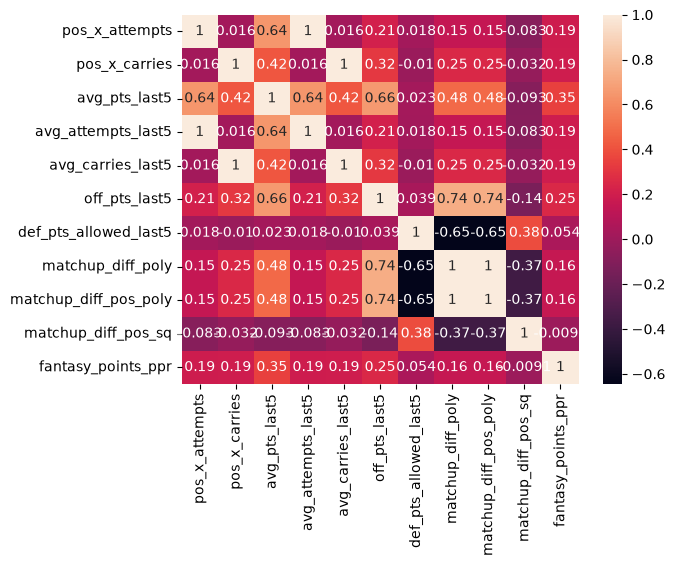

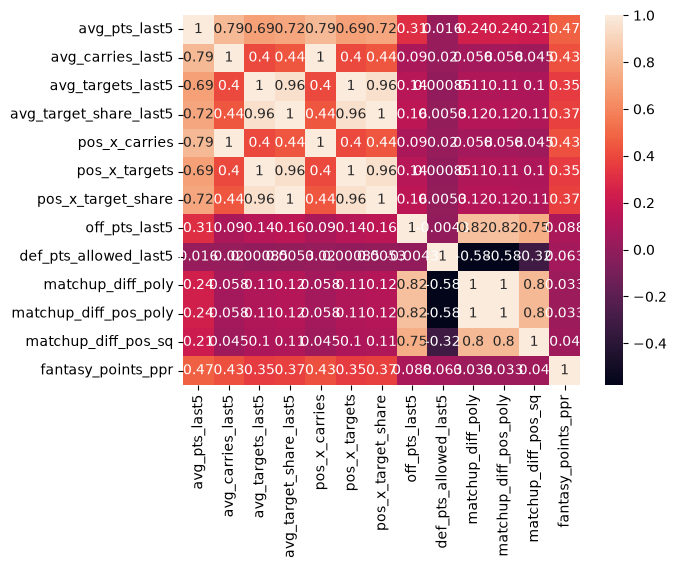

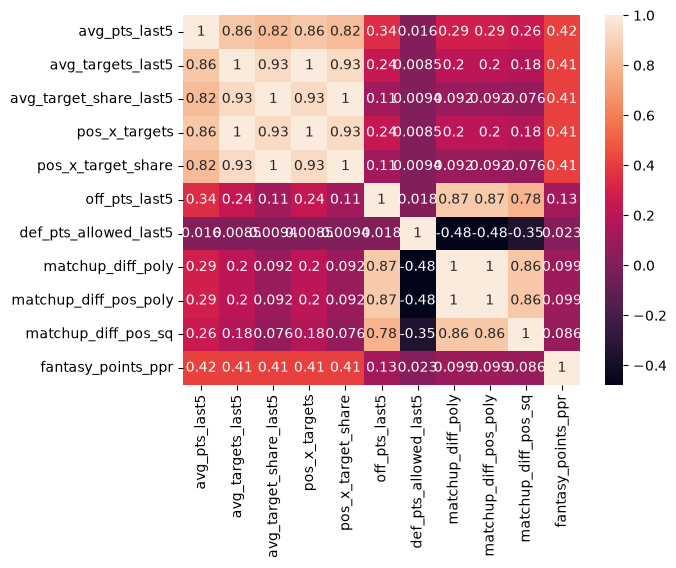

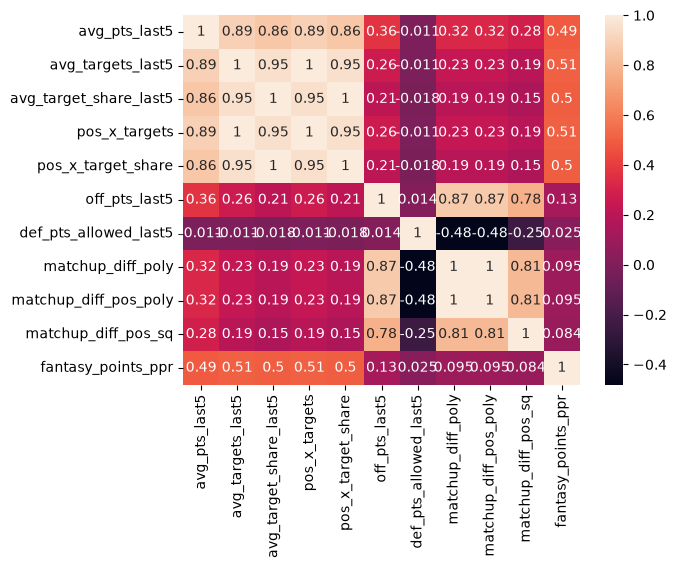

In [ ]:
corr = qb_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

corr = rb_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

corr = wr_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

corr = te_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

Since splitting was making worse performance, I thought simplifying the carries, attempts, and targets into one variable called 'opps' would help. I standardized it so that WR with 12 targets (above average) would be treated similarly to QBs with 40 attempts (also above average). The correlation ended up matching attempts, the weakest of these metrics, so this feature was dropped.

```
##### CONSOLIDATE INTO OPPS
df['pt_opps'] = 0.0

df.loc[df['position'] == 'QB', 'pt_opps'] = df['avg_attempts_last5']
df.loc[df['position'] == 'RB', 'pt_opps'] = df['avg_carries_last5']
df.loc[df['position'].isin(['WR', 'TE']), 'pt_opps'] = df['avg_targets_last5']

# standardize
for pos in ['QB', 'RB', 'WR', 'TE']:
    mask = df['position'] == pos
    mean = df.loc[mask, 'pt_opps'].mean()
    std = df.loc[mask, 'pt_opps'].std()
    df.loc[mask, 'pt_opps'] = (df.loc[mask, 'pt_opps'] - mean) / std

df['pt_opps'].plot(kind='hist')
plt.show()
```